<a href="https://colab.research.google.com/github/kalashjain9/Python-Notes/blob/main/Python_Notes_Day_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seaborn
Seaborn is a Python data visualization library built on top of matplotlib. It's designed to make it easier to create beautiful, informative, and statistical graphics with just a few lines of code.



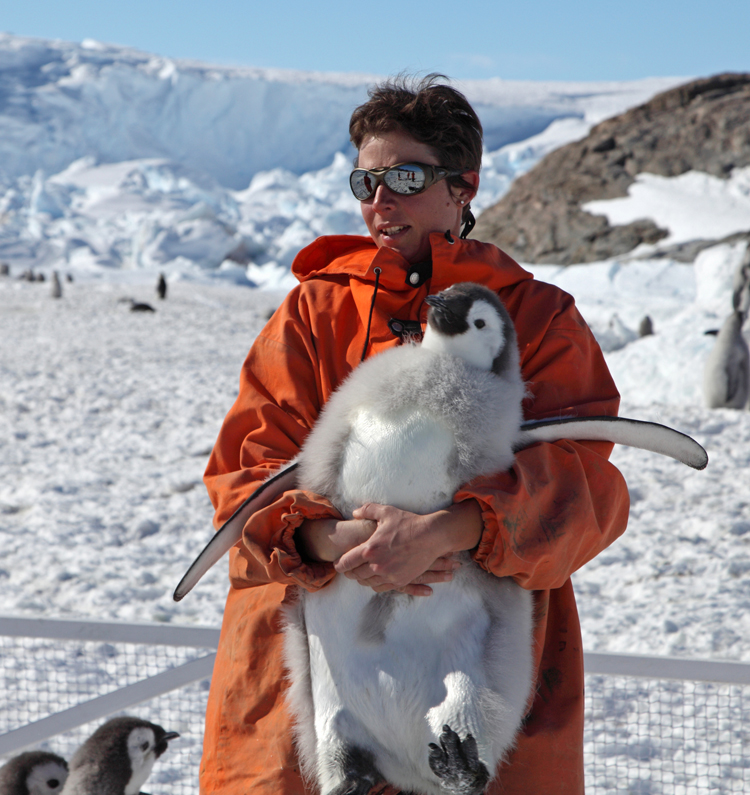

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df.sample(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
210,Chinstrap,Dream,50.2,18.8,202.0,3800.0,Male
328,Gentoo,Biscoe,43.3,14.0,208.0,4575.0,Female
211,Chinstrap,Dream,45.6,19.4,194.0,3525.0,Female
307,Gentoo,Biscoe,51.3,14.2,218.0,5300.0,Male
296,Gentoo,Biscoe,47.5,14.2,209.0,4600.0,Female
28,Adelie,Biscoe,37.9,18.6,172.0,3150.0,Female
330,Gentoo,Biscoe,50.5,15.2,216.0,5000.0,Female
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
167,Chinstrap,Dream,50.5,19.6,201.0,4050.0,Male
218,Chinstrap,Dream,50.8,19.0,210.0,4100.0,Male


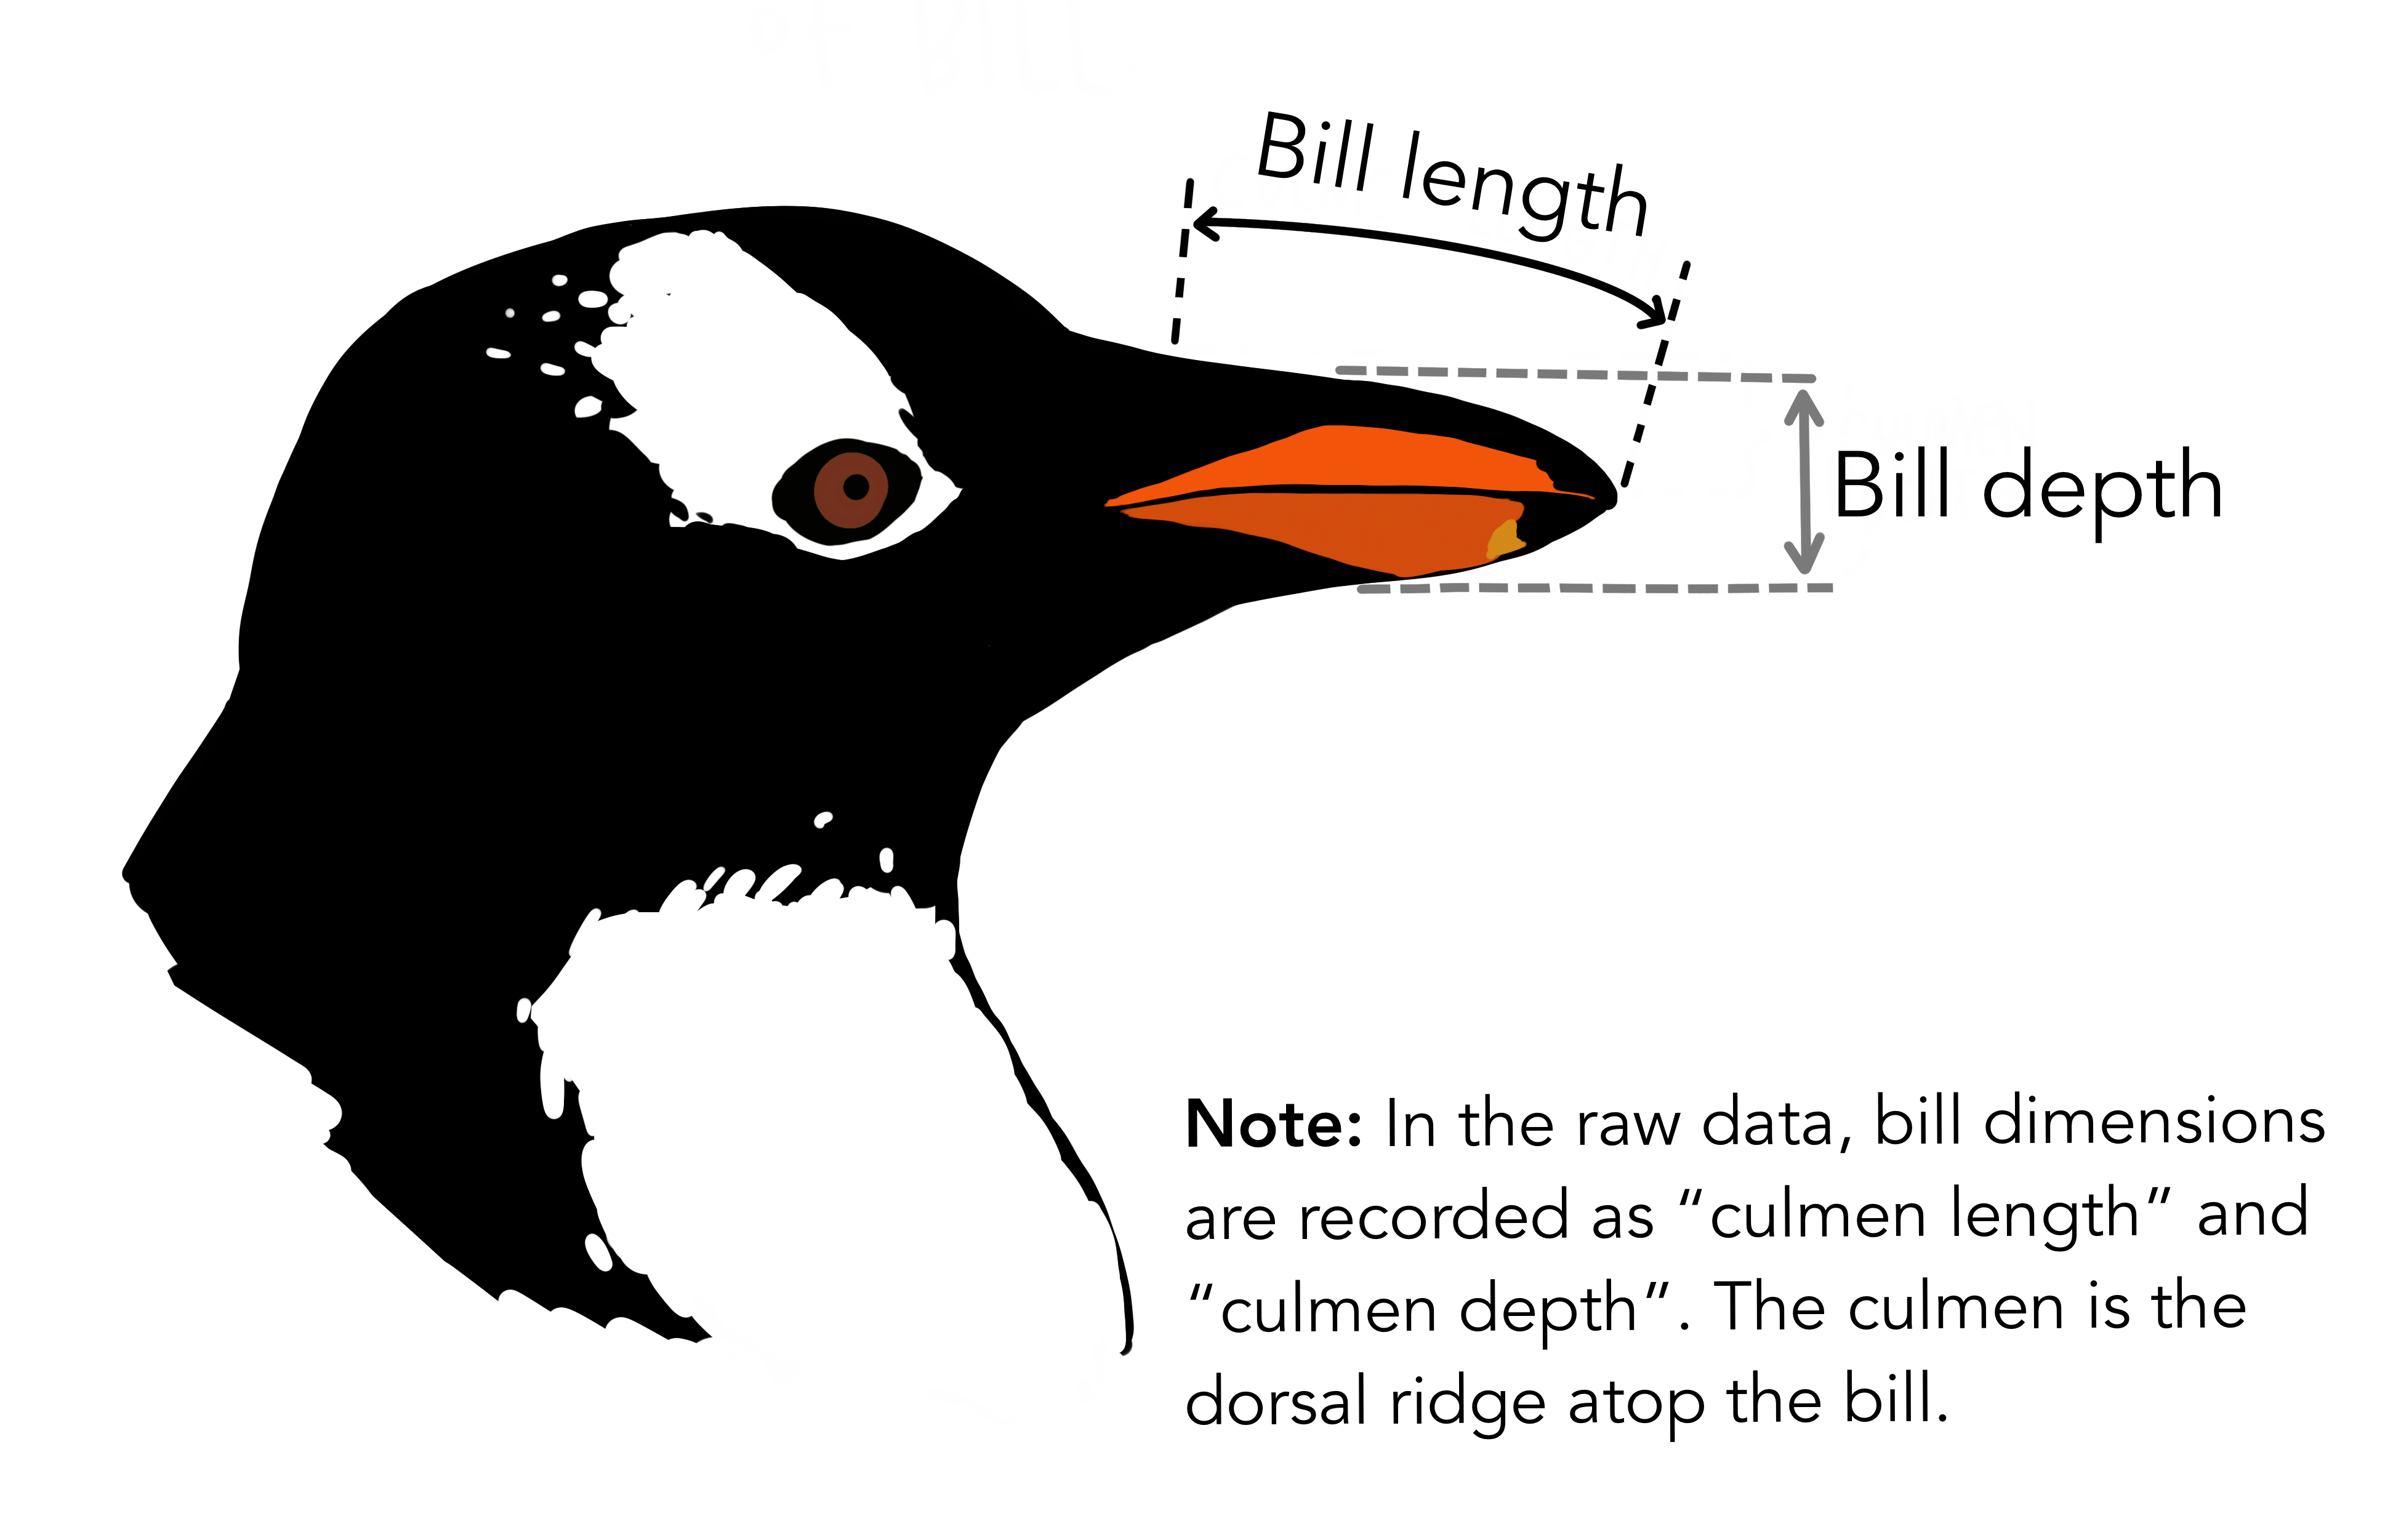

In [ ]:
import numpy as np

# All the unique values in the dataset

for col in df:
  if type(df[col][1]) != np.float64:
    print(col, df[col].unique())

species ['Adelie' 'Chinstrap' 'Gentoo']
island ['Torgersen' 'Biscoe' 'Dream']
sex ['Male' 'Female' nan]


## Scatterplot: sns.scatterplot(x, y)

### Theory

A scatterplot is used to visualize the relationship between two continuous variables. Each point represents one observation. It's a powerful way to spot trends, correlations, and outliers.

`seaborn.scatterplot()` enhances basic matplotlib scatter plots by adding aesthetics like color coding (`hue`), size mapping (`size`), and grouping (`style`).

**Syntax:**
```python
sns.scatterplot(data=df, x='column1', y='column2', hue='category_column')
```


Text(0.5, 1.0, 'Bill Dimensions by Penguin Species')

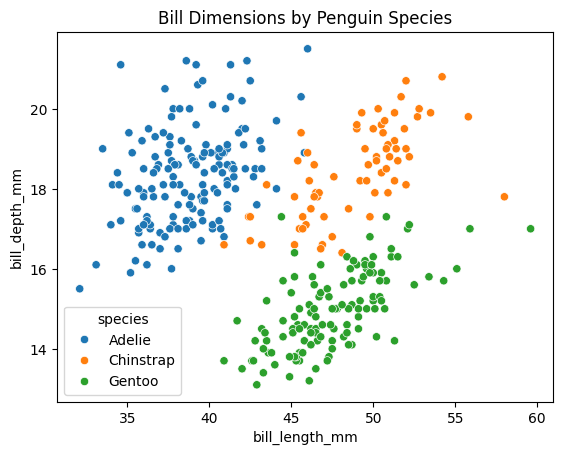

In [ ]:
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title("Bill Dimensions by Penguin Species")


## Boxplot: sns.boxplot()

### Theory

Boxplots show distributions, medians, and outliers of a numerical variable grouped by a category. Great for showing how much worse "Monsoon" makes everything.

**Syntax:**
```python
sns.boxplot(data=df, x='category_column', y='numeric_column')
```
Boxplots summarize the distribution of a numerical variable across categories.
- Minimum

- 1st Quartile (Q1)

- Median (Q2)

- 3rd Quartile (Q3)

- Maximum

- And any outliers



Text(0.5, 1.0, 'Flipper Length Distribution Across Species')

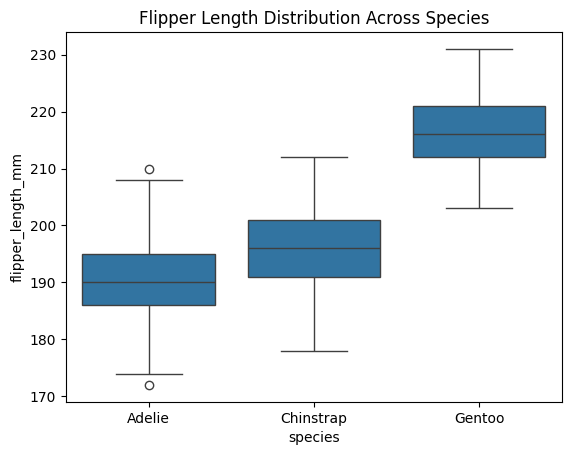

In [ ]:
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.title("Flipper Length Distribution Across Species")


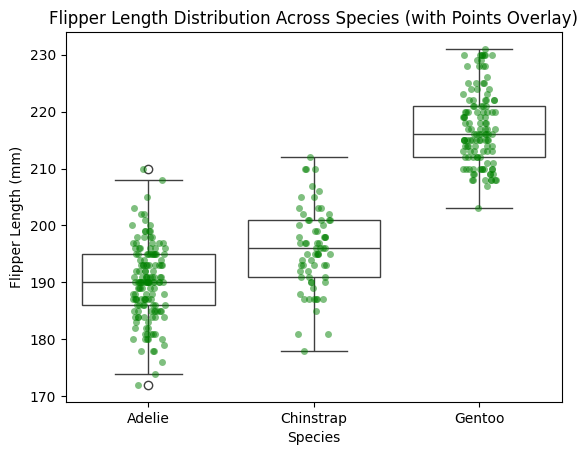

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("penguins")

# Plot the boxplot
sns.boxplot(data=df, x='species', y='flipper_length_mm', boxprops={'facecolor':'None'})
# Overlay the scatter points (with jitter for spread)
sns.stripplot(data=df, x='species', y='flipper_length_mm', color='green', alpha=0.5)

plt.title("Flipper Length Distribution Across Species (with Points Overlay)")
plt.ylabel("Flipper Length (mm)")
plt.xlabel("Species")
plt.show()


## Heatmap: sns.heatmap(corr_matrix)

### Theory

A heatmap shows matrix-style data (like correlation matrices) using color gradients. It's perfect for visualizing how numerical features relate to each other.

You typically pass a correlation matrix (`df.corr()`) to `sns.heatmap()`.

**Syntax:**
```python
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
```
- 1 means perfect positive relationship (as one increases, so does the other)

- -1 means perfect negative relationship (as one increases, the other decreases)

- 0 means no linear relation



In [ ]:
df.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

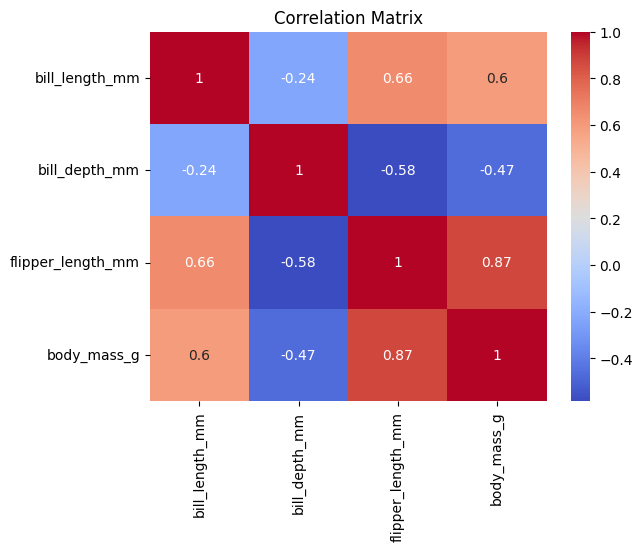

In [ ]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")


## Pairplot: sns.pairplot(df)

### Theory

Pairplots plot pairwise relationships between numerical columns in a dataset. It creates a grid of scatterplots for each pair of features and histograms on the diagonals. It's commonly used for Exploratory Data Analysis (EDA).

**Syntax:**
```python
sns.pairplot(df, hue='category_column')
```

You can also filter which columns to include using `vars=[...]`.


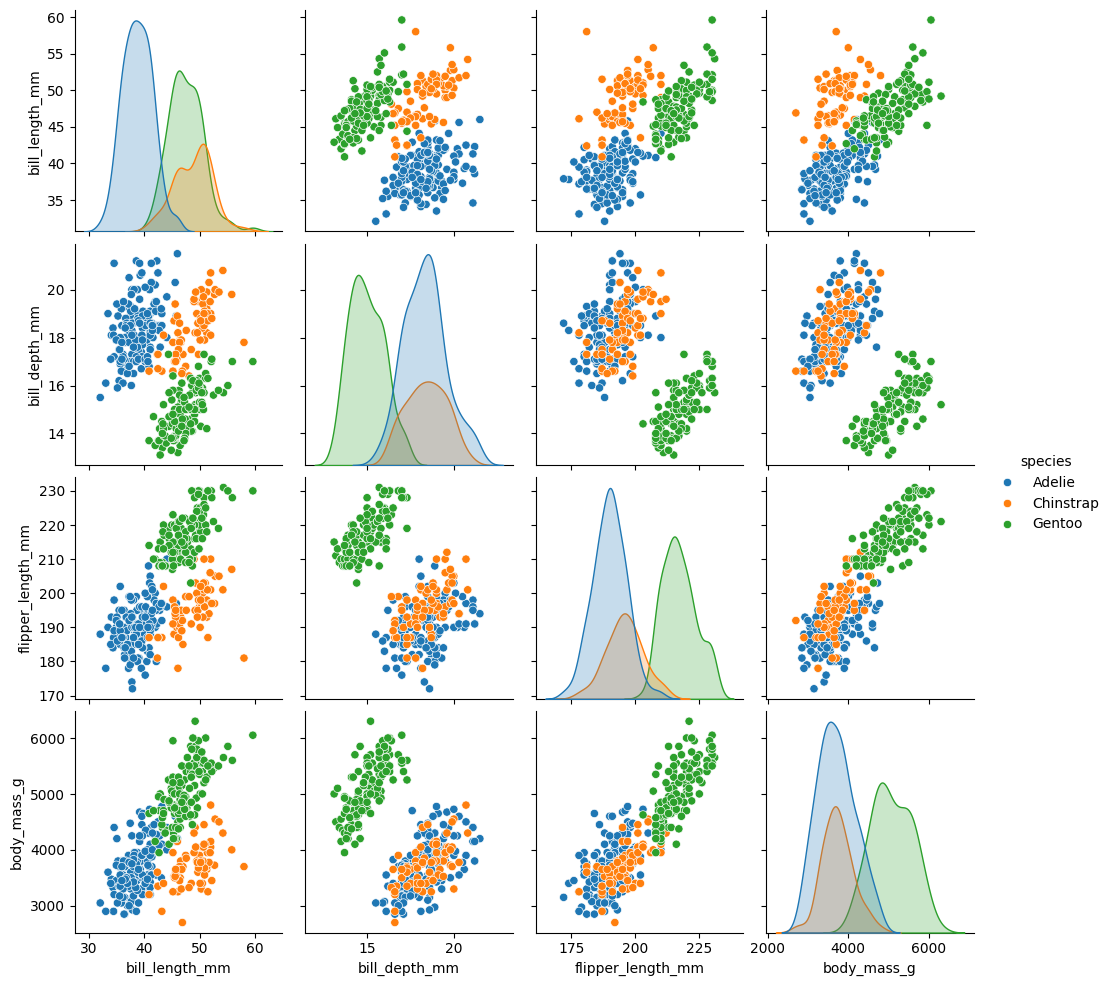

In [ ]:
sns.pairplot(df, hue='species')

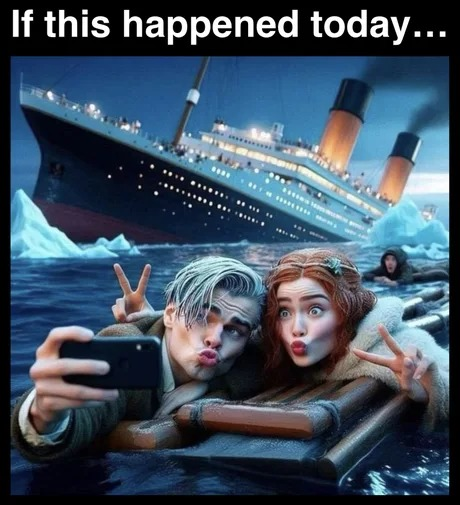

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")
df.sample(10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
735,0,3,male,28.5,0,0,16.1000,S,Third,man,True,NaN,Southampton,no,True
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
741,0,1,male,36.0,1,0,78.8500,S,First,man,True,C,Southampton,no,False
453,1,1,male,49.0,1,0,89.1042,C,First,man,True,C,Cherbourg,yes,False
752,0,3,male,33.0,0,0,9.5000,S,Third,man,True,NaN,Southampton,no,True
751,1,3,male,6.0,0,1,12.4750,S,Third,child,False,E,Southampton,yes,False
182,0,3,male,9.0,4,2,31.3875,S,Third,child,False,NaN,Southampton,no,False
267,1,3,male,25.0,1,0,7.7750,S,Third,man,True,NaN,Southampton,yes,False
163,0,3,male,17.0,0,0,8.6625,S,Third,man,True,NaN,Southampton,no,True
142,1,3,female,24.0,1,0,15.8500,S,Third,woman,False,NaN,Southampton,yes,False


### Quiz 1


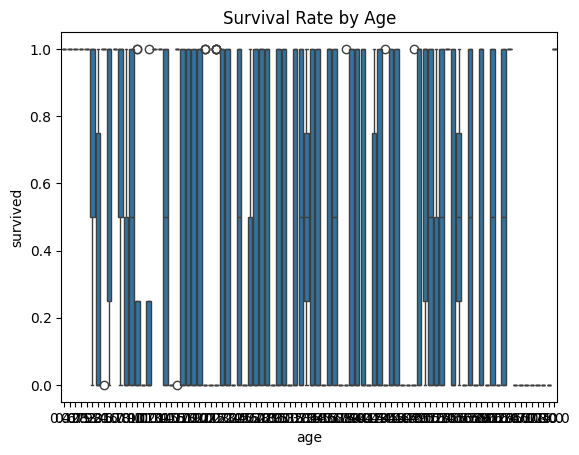

In [ ]:
sns.boxplot(data=df, x='age', y='survived')
plt.title("Survival Rate by Age")
plt.show()

### Answer

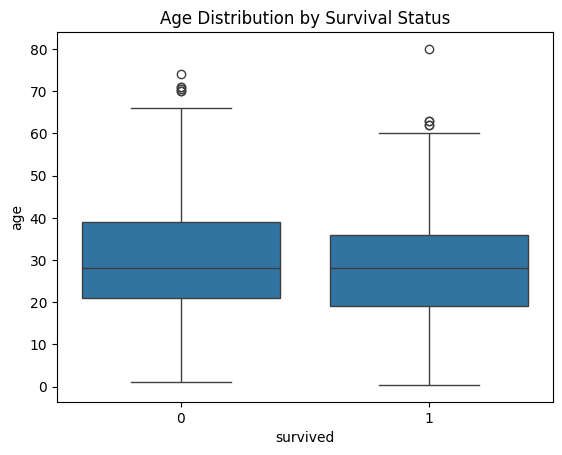

In [ ]:
sns.boxplot(data=df, x='survived', y='age')
plt.title("Age Distribution by Survival Status")
plt.show()


### Quiz 2

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Titanic Feature Correlations")
plt.show()


ValueError: could not convert string to float: 'male'

### Answer

<Axes: >

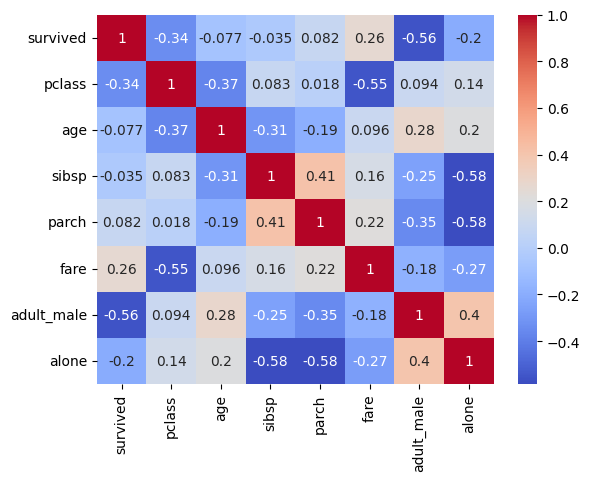

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')


# ***Thank U***

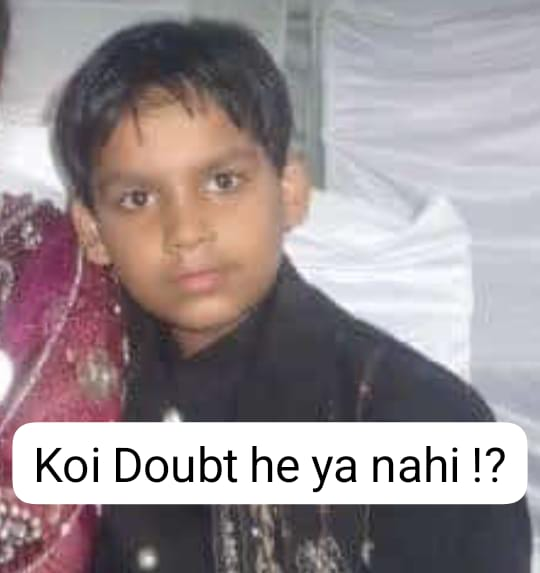

## HOMEWORK FOR Y'ALL

- Load the Titanic dataset using sns.load_dataset("titanic"). Create a scatterplot between age and fare, colored by class. What pattern do you see in pricing for different age groups?

- Generate a boxplot comparing fare across different embark_towns. Which town had the highest variability in ticket prices?

- Compute and plot a heatmap of the correlation matrix for the numeric columns in the Titanic dataset. Which variables are highly correlated?

- Filter the data to only passengers under age 30 and then plot a pairplot. Did survival patterns or class preference change for younger people?

